In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder #species: changes into numbers
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import accuracy_score
sns.set_style("whitegrid")

In [2]:
df=pd.read_csv("/kaggle/input/datasets/faheemrasool12/penguins-lter-csv/penguins_lter.csv")

In [3]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Gender',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'],
      dtype='object')

In [4]:
df.info

<bound method DataFrame.info of     studyName  Sample Number                              Species  Region  \
0     PAL0708              1  Adelie Penguin (Pygoscelis adeliae)  Anvers   
1     PAL0708              2  Adelie Penguin (Pygoscelis adeliae)  Anvers   
2     PAL0708              3  Adelie Penguin (Pygoscelis adeliae)  Anvers   
3     PAL0708              4  Adelie Penguin (Pygoscelis adeliae)  Anvers   
4     PAL0708              5  Adelie Penguin (Pygoscelis adeliae)  Anvers   
..        ...            ...                                  ...     ...   
339   PAL0910            120    Gentoo penguin (Pygoscelis papua)  Anvers   
340   PAL0910            121    Gentoo penguin (Pygoscelis papua)  Anvers   
341   PAL0910            122    Gentoo penguin (Pygoscelis papua)  Anvers   
342   PAL0910            123    Gentoo penguin (Pygoscelis papua)  Anvers   
343   PAL0910            124    Gentoo penguin (Pygoscelis papua)  Anvers   

        Island               Stage Individu

In [5]:
features =[
    'Culmen Length (mm)',
    'Culmen Depth (mm)', 
    'Flipper Length (mm)', 
    'Body Mass (g)'
]
target_species="Species"

In [6]:
df_nulls=df[df[features].isnull().any(axis=1)]
df_nulls

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Gender,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
339,PAL0910,120,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A2,No,12/01/2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


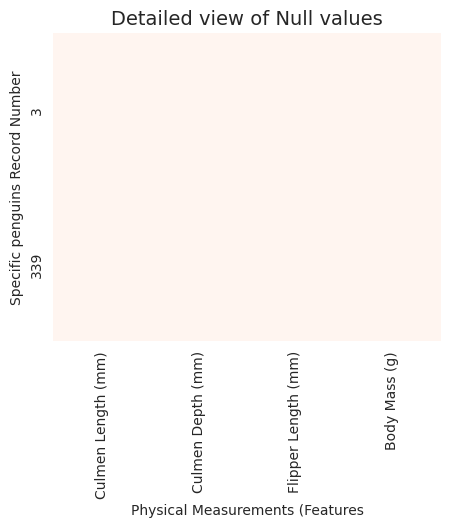

In [7]:
plt.figure(figsize=(5,4))
sns.heatmap(
    df_nulls[features].isnull(),
    yticklabels=True,
    cbar=False,
    cmap="Reds"
)
plt.title("Detailed view of Null values",fontsize=14)
plt.xlabel("Physical Measurements (Features")
plt.ylabel("Specific penguins Record Number")
plt.show()

In [8]:
df_clean=df.dropna(subset=features+[target_species]).copy()

In [9]:
df_clean[features].isnull()

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
4,False,False,False,False
5,False,False,False,False
...,...,...,...,...
338,False,False,False,False
340,False,False,False,False
341,False,False,False,False
342,False,False,False,False


In [10]:
df_clean["Species"]=df_clean["Species"].apply(lambda x: x.split()[0])

In [11]:
print(f"Original Dataset has the {len(df)}rows")
print(f"Cleaned Dataset has the {len(df_clean)}rows")

Original Dataset has the 344rows
Cleaned Dataset has the 342rows


In [12]:
X=df_clean["Flipper Length (mm)"]
Y=df_clean["Body Mass (g)"]
species=df_clean["Species"]
print(f'The X values or predictor Values are{X}')
print(f'The Y values or Target Values are{Y}')


The X values or predictor Values are0      181.0
1      186.0
2      195.0
4      193.0
5      190.0
       ...  
338    214.0
340    215.0
341    222.0
342    212.0
343    213.0
Name: Flipper Length (mm), Length: 342, dtype: float64
The Y values or Target Values are0      3750.0
1      3800.0
2      3250.0
4      3450.0
5      3650.0
        ...  
338    4925.0
340    4850.0
341    5750.0
342    5200.0
343    5400.0
Name: Body Mass (g), Length: 342, dtype: float64


In [13]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

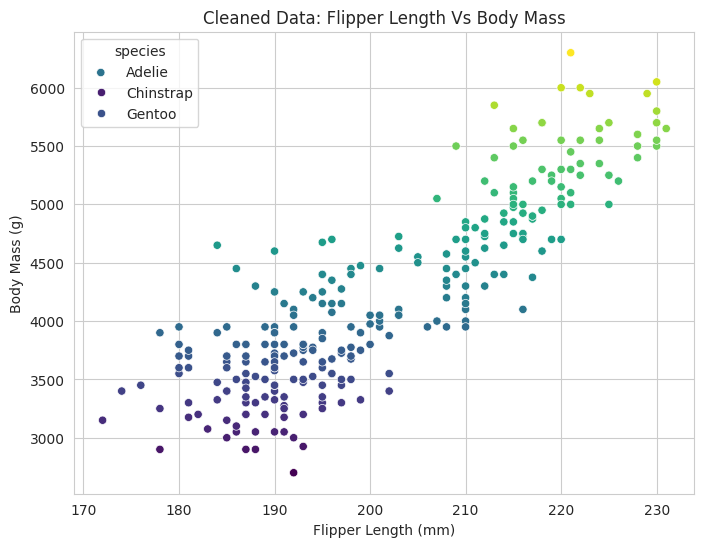

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_train,
    y=Y_train,
    hue=Y_train,
    palette="viridis"
)
plt.title("Cleaned Data: Flipper Length Vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend(title="species", labels=["Adelie","Chinstrap","Gentoo"])
plt.show()

In [17]:
lin_model=LinearRegression()
lin_model.fit(X_train.values.reshape(-1,1),Y_train)

LinearRegression()

In [22]:
y_pred=lin_model.predict(X_test.values.reshape(-1,1))

In [23]:
y_pred

array([4591.33658856, 4103.03976037, 3712.40229782, 3956.55071192,
       3907.7210291 , 4542.50690574, 4200.69912601, 3712.40229782,
       5226.12246521, 3321.76483527, 4103.03976037, 4884.31468548,
       4591.33658856, 4884.31468548, 4054.21007755, 3956.55071192,
       3614.74293218, 3907.7210291 , 3077.61642117, 3468.25388373,
       3810.06166346, 3468.25388373, 4737.82563702, 3517.08356654,
       3663.572615  , 4396.01785729, 4005.38039473, 3712.40229782,
       3810.06166346, 5226.12246521, 4151.86944319, 3272.93515245,
       3370.59451809, 4786.65531984, 3907.7210291 , 3224.10546963,
       4249.52880883, 4786.65531984, 3712.40229782, 3370.59451809,
       3858.89134628, 3810.06166346, 5128.46309957, 4542.50690574,
       3126.44610399, 3956.55071192, 5274.95214803, 5372.61151367,
       3663.572615  , 3907.7210291 , 4640.16627138, 3517.08356654,
       4640.16627138, 3810.06166346, 3370.59451809, 3517.08356654,
       3224.10546963, 5616.75992776, 5567.93024494, 3272.93515

In [28]:
Y_mean=np.full_like(Y_test,Y_train.mean())

In [30]:
mse_base=mean_squared_error(Y_test,Y_mean)
rmse_base=np.sqrt(mse_base)
r2_base=r2_score(Y_test,Y_mean)
print(f"Mean Square Error Before Fitting is {mse_base}")
print(f"Root Mean Square Error before fitting is {rmse_base}")
print(f"R Square before fitting is{r2_base}")

Mean Square Error Before Fitting is 671730.445458348
Root Mean Square Error before fitting is 819.5916333506267
R Square before fitting is-0.010245413956642802


In [37]:
y_pred=lin_model.predict(X_test.values.reshape(-1,1))
mse_model=mean_squared_error(Y_test,y_pred)
rmse_model=np.sqrt(mse_model)
r2_model=r2_score(Y_test,y_pred)
print(f"Mean Square Error After Fitting is {mse_model}")
print(f"Root Mean Square Error After fitting is {rmse_model}")
print(f"R Square After fitting is{r2_model}")

Mean Square Error After Fitting is 144928.59331305986
Root Mean Square Error After fitting is 380.6948821734538
R Square After fitting is0.7820354165340795


In [38]:
print("------Results of linear Regression------")
print(f"Root mean square of baseline is {rmse_base: .2f}g")
print(f"Root mean square of model is {rmse_model: .2f}g")
print(f"R square of baseline is {r2_base}g")
print(f"R square of modek is {r2_model} g")

------Results of linear Regression------
Root mean square of baseline is  819.59g
Root mean square of model is  380.69g
R square of baseline is -0.010245413956642802g
R square of modek is 0.7820354165340795 g


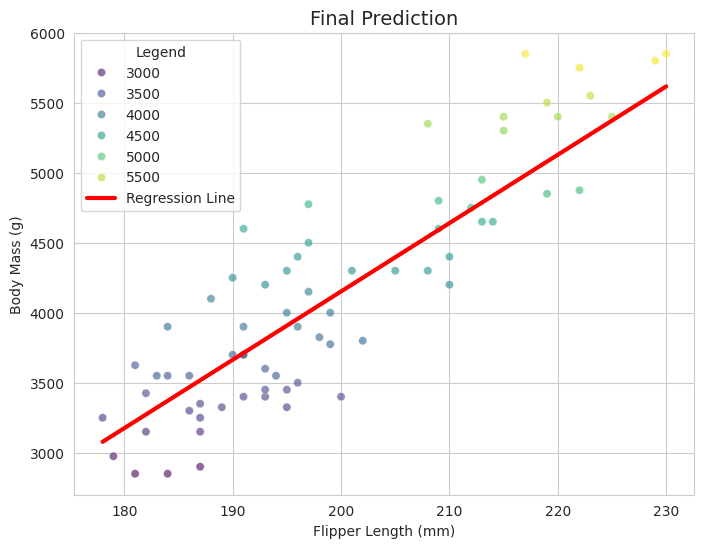

In [59]:
# Pehle numpy mein convert karo
x_test_np = X_test.values
y_test_np = Y_test.values

# Sort karo
sorted_idx = np.argsort(x_test_np)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x = x_test_np,
    y = y_test_np,
    hue = Y_test.values,   # ✅ Species colors ke liye
    palette = "viridis",
    alpha = 0.6
)

plt.plot(
    x_test_np[sorted_idx],          # ✅ sorted x
    y_pred[sorted_idx],             # ✅ sorted predictions
    color = "red",
    linewidth = 3,
    label = "Regression Line"
)

plt.title("Final Prediction", fontsize=14)
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend(title="Legend")          # ✅ manual labels mat do
plt.show()

In [64]:
import warnings
warnings.filterwarnings("ignore")
X_species=df_clean[features]
le=LabelEncoder()
y_species=le.fit_transform(df_clean["Species"])
species_model=LogisticRegression(max_iter=1000)
species_model.fit(X_species,y_species)

LogisticRegression(max_iter=1000)